# EDA
## BoT-IoT | CICIoT2023 | UNSW-NB15 | q8 Parquet vs. CSV | Class Distributions

## Setup

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import torch

In [2]:
from scripts.data import (
    load_split,
    plot_class_balance_bars,
    plot_class_balance_pie,
)
from scripts.utils import to_np_y

In [3]:
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available?: {torch.cuda.is_available()}")

if torch.cuda.is_available():
    print(f"CUDA device name: {torch.cuda.get_device_name(0)}")
    print(f"Current CUDA device index: {torch.cuda.current_device()}")

PyTorch version: 2.12.1+cu126
CUDA available?: True
CUDA device name: NVIDIA GeForce GTX 1060
Current CUDA device index: 0


## Dataset: BoT-IoT

In [4]:
dataset = "BoT-IoT"
dataset_alt = "BoT-IoT"

data_path = f"data/{dataset}/quantum"
data_path_alt = f"data/{dataset_alt}/quantum"

data_path_csv = f"data/FROZEN/{dataset}"
data_path_csv_alt = f"data/FROZEN/{dataset_alt}"

frozen_feat_path = "team-artifacts/teamC_week3_FROZEN_handoff.json"

target_col = "label_multiclass"
split_prefix = "q8"

In [5]:
df_p = pd.read_parquet(f"{data_path}/{split_prefix}_train.parquet")
df_p.head()

,rate,n_bytes_total,rate_src,dst_pkts,n_pkts_total,dst_bytes,src_bytes,src_pkts,label_multiclass,label_binary,label_family
0,0.030780,0.332164,0.032406,0.0,0.295669,0.0,0.395761,0.295669,DoS,1,dos
1,0.040153,0.429708,0.042274,0.0,0.404791,0.0,0.491098,0.404791,DoS,1,dos
2,0.114465,0.476056,0.120511,0.0,0.458797,0.0,0.536396,0.458797,DDoS,1,ddos
3,0.051103,0.527890,0.053802,0.0,0.295669,0.0,0.587057,0.295669,DDoS,1,ddos
4,0.018999,0.421771,0.020003,0.0,0.186546,0.0,0.483341,0.186546,DoS,1,dos


In [6]:
df_c = pd.read_csv(f"{data_path_csv}/train.csv")
df_c.head()

,duration,n_pkts_total,n_bytes_total,src_pkts,dst_pkts,src_bytes,dst_bytes,rate,rate_src,rate_dst,pkt_size_min,pkt_size_max,pkt_size_mean,pkt_size_std,iat,protocol,conn_state,label_multiclass,label_binary,label_family
0,0.266991,-0.262256,-0.798644,0.000000,0.0,-0.774964,0.0,-0.356930,-0.312505,0.0,0.000000,0.123458,-0.266091,0.827772,0.0,0.0,0.0,DoS,1,dos
1,0.566762,0.427561,-0.121016,0.500000,0.0,0.000000,0.0,-0.123704,-0.065473,0.0,0.000000,0.120431,0.030826,0.766490,0.0,0.0,0.0,DoS,1,dos
2,-0.483644,0.768961,0.200956,0.747457,0.0,0.368220,0.0,1.725276,1.892957,0.0,0.761987,0.244690,0.422755,0.618673,0.0,0.0,0.0,DDoS,1,ddos
3,-0.331447,-0.262256,0.561042,0.000000,0.0,0.780030,0.0,0.148742,0.223100,0.0,0.000000,-0.189617,0.009431,0.536541,0.0,-1.0,-1.0,DDoS,1,ddos
4,0.065895,-0.952073,-0.176151,-0.500000,0.0,-0.063055,0.0,-0.650047,-0.622973,0.0,0.000000,-0.288760,-0.209436,0.466893,0.0,-1.0,-1.0,DoS,1,dos


In [7]:
# check label columns
print("=" * 25, " Parquet labels ", "=" * 25)
print(df_p["label_multiclass"].unique())
print()
print(df_p["label_family"].unique())
print()
print("=" * 25, " CSV labels ", "=" * 25)
print(df_c["label_multiclass"].unique())
print()
print(df_c["label_family"].unique())

=========================  Parquet labels  =========================
<ArrowStringArray>
['DoS', 'DDoS', 'Reconnaissance', 'Normal']
Length: 4, dtype: str

<ArrowStringArray>
['dos', 'ddos', 'recon', 'benign']
Length: 4, dtype: str

=========================  CSV labels  =========================
<ArrowStringArray>
['DoS', 'DDoS', 'Reconnaissance', 'Normal']
Length: 4, dtype: str

<ArrowStringArray>
['dos', 'ddos', 'recon', 'benign']
Length: 4, dtype: str


In [8]:
# check NaNs
has_nan_p = df_p[target_col].isna().any()
has_nan_c = df_c[target_col].isna().any()
print(f"Parquet data has NaNs: {has_nan_p}")
print(f"CSV data has NaNs: {has_nan_c}")

Parquet data has NaNs: False
CSV data has NaNs: False


In [9]:
# get labels
class_names = sorted(df_p[target_col].dropna().unique())
class_names

['DDoS', 'DoS', 'Normal', 'Reconnaissance']

In [10]:
# load all data
try:
    X_train_full, y_train_full = load_split(
        data_path, f"{split_prefix}_train", target_col, class_names
    )
    X_val_full, y_val_full = load_split(
        data_path, f"{split_prefix}_val", target_col, class_names
    )
    X_cal_full, y_cal_full = load_split(
        data_path, f"{split_prefix}_calibration", target_col, class_names
    )
    X_test_full, y_test_full = load_split(
        data_path, f"{split_prefix}_test", target_col, class_names
    )
    X_zero_full, y_zero_full = load_split(
        data_path, f"{split_prefix}_zeroday", target_col, class_names
    )

    X_train_full_csv, y_train_full_csv = load_split(
        data_path_csv, "train", target_col, class_names, csv=True
    )
    X_cal_full_csv, y_cal_full_csv = load_split(
        data_path_csv, "calibration", target_col, class_names, csv=True
    )
    X_test_full_csv, y_test_full_csv = load_split(
        data_path_csv, "test", target_col, class_names, csv=True
    )
    X_zero_full_csv, y_zero_full_csv = load_split(
        data_path_csv, "zeroday", target_col, class_names, csv=True
    )
except:
    print("Fallback to another dataset location...")
    X_train_full, y_train_full = load_split(
        data_path_alt, f"{split_prefix}_train", target_col, class_names
    )
    X_val_full, y_val_full = load_split(
        data_path_alt, f"{split_prefix}_val", target_col, class_names
    )
    X_cal_full, y_cal_full = load_split(
        data_path_alt, f"{split_prefix}_calibration", target_col, class_names
    )
    X_test_full, y_test_full = load_split(
        data_path_alt, f"{split_prefix}_test", target_col, class_names
    )
    X_zero_full, y_zero_full = load_split(
        data_path_alt, f"{split_prefix}_zeroday", target_col, class_names
    )

    X_train_full_csv, y_train_full_csv = load_split(
        data_path_csv_alt, "train", target_col, class_names, csv=True
    )
    X_cal_full_csv, y_cal_full_csv = load_split(
        data_path_csv_alt, "calibration", target_col, class_names, csv=True
    )
    X_test_full_csv, y_test_full_csv = load_split(
        data_path_csv_alt, "test", target_col, class_names, csv=True
    )
    X_zero_full_csv, y_zero_full_csv = load_split(
        data_path_csv_alt, "zeroday", target_col, class_names, csv=True
    )

# check shape
print(
    f"train_parquet : {X_train_full.shape, y_train_full.shape}\n\
val_parquet   : {X_val_full.shape, y_val_full.shape}\n\
cal_parquet   : {X_cal_full.shape, y_cal_full.shape}\n\
test_parquet  : {X_test_full.shape, y_test_full.shape}\n\
zero_parquet  : {X_zero_full.shape, y_zero_full.shape}\n\
train_csv     : {X_train_full_csv.shape, y_train_full_csv.shape}\n\
cal_csv       : {X_cal_full_csv.shape, y_cal_full_csv.shape}\n\
test_csv      : {X_test_full_csv.shape, y_test_full_csv.shape}\n\
zero_csv      : {X_zero_full_csv.shape, y_zero_full_csv.shape}\n"
)

train_parquet : ((130138, 8), (130138,))
val_parquet   : ((18591, 8), (18591,))
cal_parquet   : ((18591, 8), (18591,))
test_parquet  : ((18591, 8), (18591,))
zero_parquet  : ((683, 8), (683,))
train_csv     : ((148729, 17), (148729,))
cal_csv       : ((18591, 17), (18591,))
test_csv      : ((18591, 17), (18591,))
zero_csv      : ((683, 17), (683,))



In [11]:
# load FROZEN features
handoff = json.loads(Path(frozen_feat_path).read_text())

try:
    FEATURE_COLS = list(handoff["frozen_subsets"][dataset]["features"])
    print(f"Team C selector: {handoff['frozen_subsets'][dataset]['selector']}")
except:
    print("Fallback to another dataset location...")
    FEATURE_COLS = list(handoff["frozen_subsets"][dataset_alt]["features"])
    print(f"Team C selector: {handoff['frozen_subsets'][dataset_alt]['selector']}")
print(f"k={len(FEATURE_COLS)} features: {FEATURE_COLS}")

Fallback to another dataset location...
Team C selector: QIGPSO
k=10 features: ['n_pkts_total', 'n_bytes_total', 'src_bytes', 'rate', 'pkt_size_min', 'pkt_size_max', 'pkt_size_mean', 'pkt_size_std', 'protocol', 'conn_state']


In [12]:
# check CSV train is a combination
data_combined = X_train_full.shape[0] + X_val_full.shape[0] == X_train_full_csv.shape[0]
data_combined_col = X_train_full.shape[1] < X_train_full_csv.shape[1]
print(f"Row-wise: Parquet train + Parquet val = CSV train?: {data_combined}")
print(f"Col-wise: Parquet train < CSV train (more feature)?: {data_combined_col}")
print("=" * 100)

# check if other sets are same: Parquet vs CSV
same_size_cal = X_cal_full.shape[0] == X_cal_full_csv.shape[0]
same_size_test = X_test_full.shape[0] == X_test_full_csv.shape[0]
same_size_zero = X_zero_full.shape[0] == X_zero_full_csv.shape[0]
print(f"Row-wise: Parquet cal = CSV cal? : {same_size_cal}")
print(f"Row-wise: Parquet test = CSV test? : {same_size_cal}")
print(f"Row-wise: Parquet zero = CSV zero? : {same_size_cal}")
print("=" * 100)

# check columns
p_cols, c_cols, fro_cols = set(df_p.columns), set(df_c.columns), set(FEATURE_COLS)
print(f"Parquet has these cols: {p_cols}")
print()
print(f"CSV has these cols: {c_cols}")
print()
print(f"We want these cols: {fro_cols}")
print("=" * 100)

# FROZEN features: Parquet or CSV
p_has_all_fros = len(fro_cols - p_cols) == 0
c_has_all_fros = len(fro_cols - c_cols) == 0
print(f"Does Parquet train have required FROZEN features?: {p_has_all_fros}")
print(f"Does CSV train have required FROZEN features?: {c_has_all_fros}")

Row-wise: Parquet train + Parquet val = CSV train?: True
Col-wise: Parquet train < CSV train (more feature)?: True
Row-wise: Parquet cal = CSV cal? : True
Row-wise: Parquet test = CSV test? : True
Row-wise: Parquet zero = CSV zero? : True
Parquet has these cols: {'n_pkts_total', 'src_pkts', 'label_family', 'dst_pkts', 'label_multiclass', 'n_bytes_total', 'src_bytes', 'label_binary', 'dst_bytes', 'rate', 'rate_src'}

CSV has these cols: {'duration', 'label_multiclass', 'rate_dst', 'dst_bytes', 'pkt_size_max', 'src_pkts', 'src_bytes', 'pkt_size_std', 'iat', 'label_binary', 'rate', 'n_pkts_total', 'pkt_size_mean', 'label_family', 'pkt_size_min', 'n_bytes_total', 'conn_state', 'rate_src', 'dst_pkts', 'protocol'}

We want these cols: {'n_pkts_total', 'pkt_size_mean', 'pkt_size_min', 'n_bytes_total', 'conn_state', 'src_bytes', 'pkt_size_std', 'protocol', 'pkt_size_max', 'rate'}
Does Parquet train have required FROZEN features?: False
Does CSV train have required FROZEN features?: True


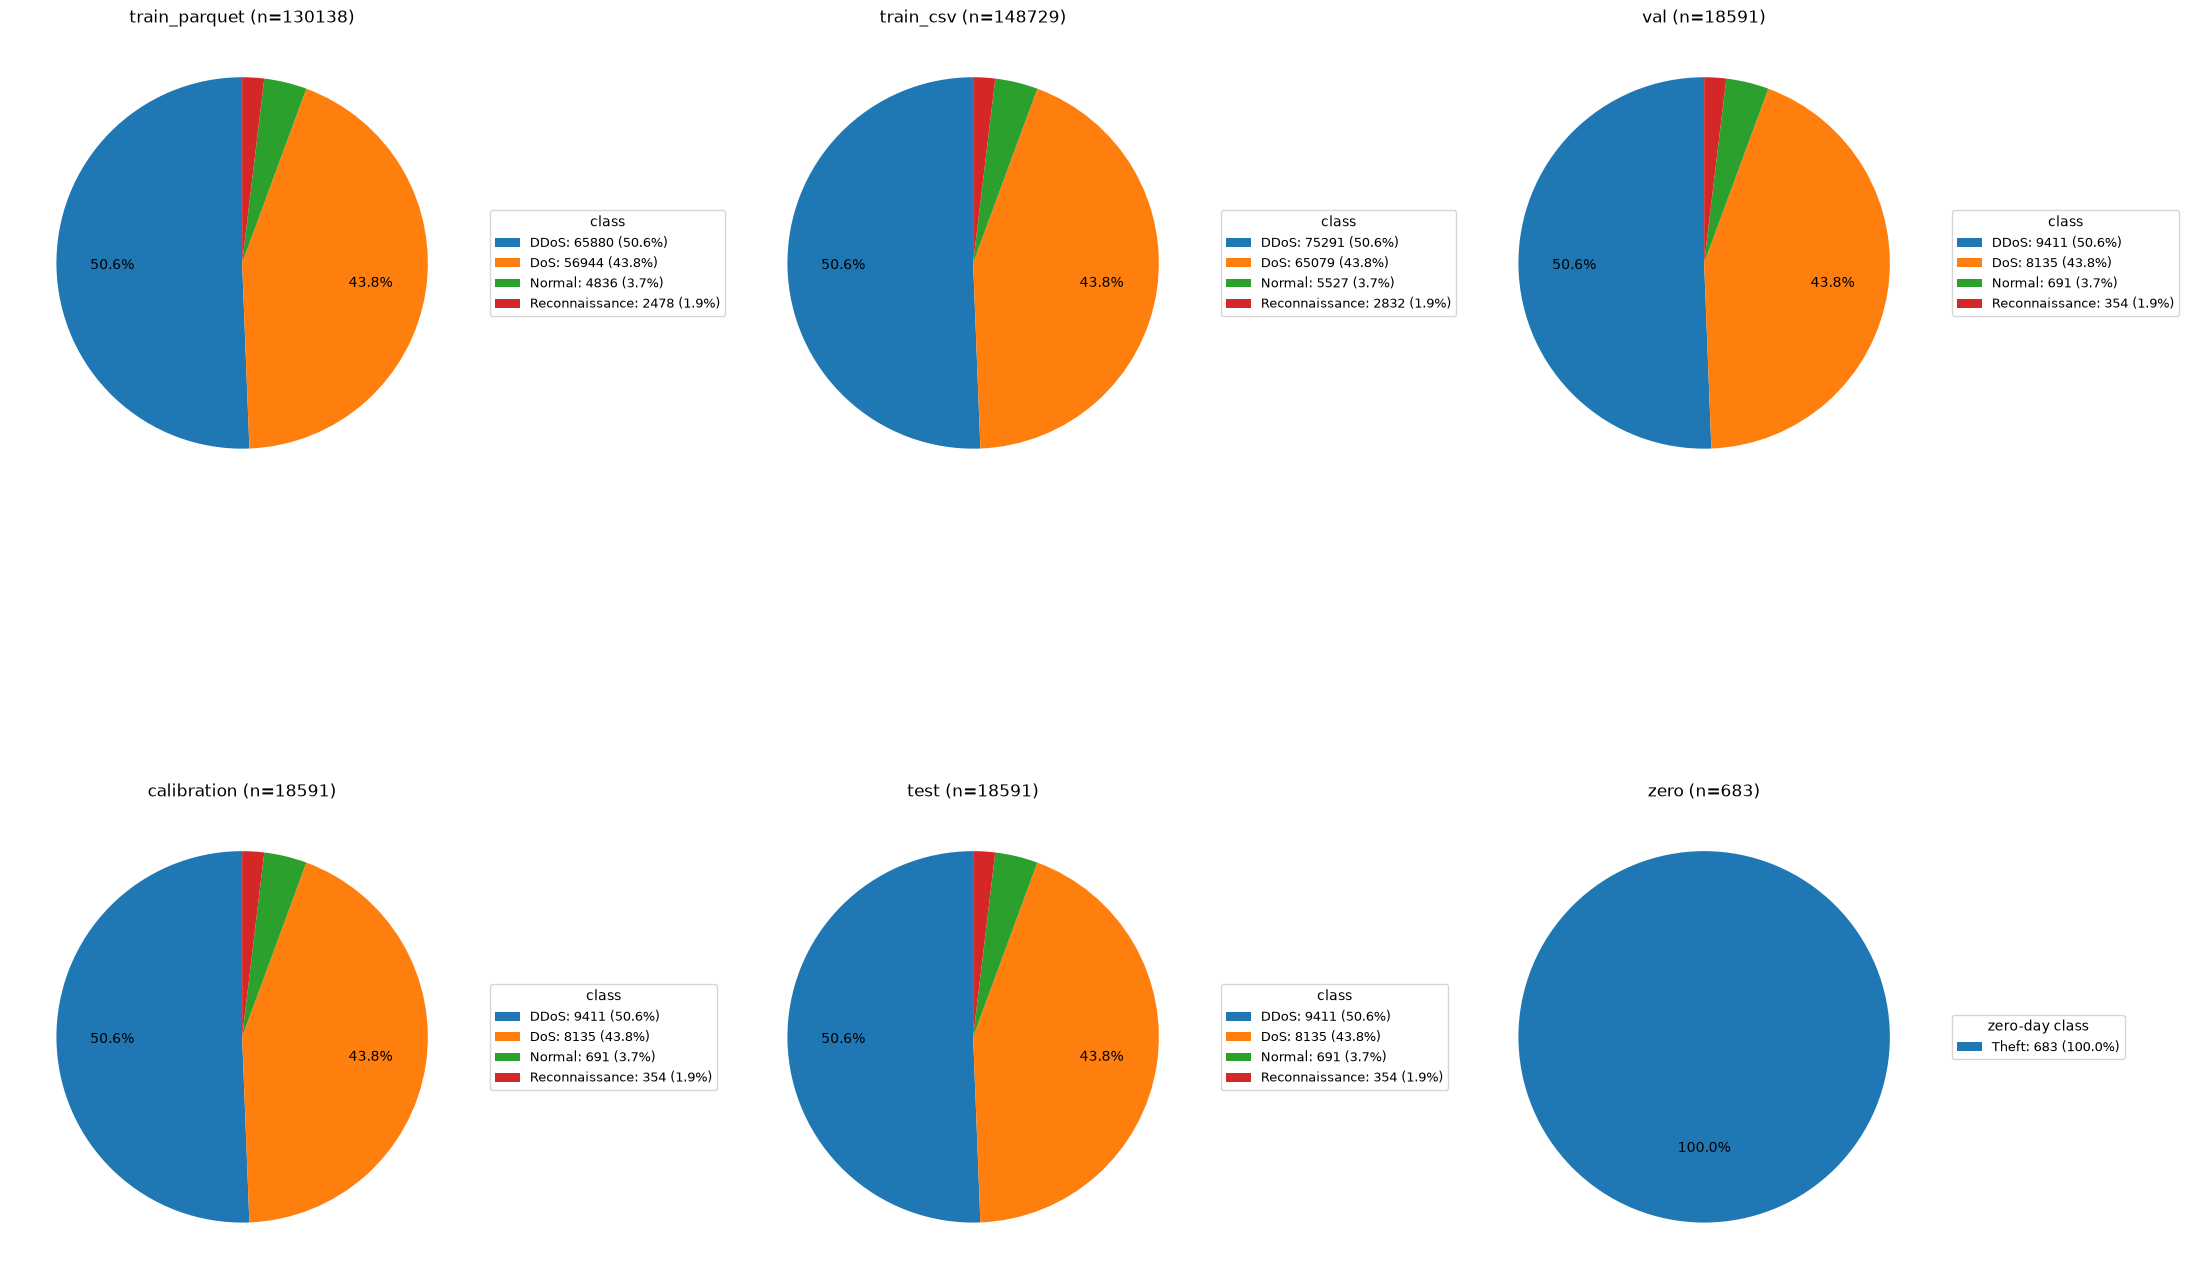

In [13]:
# class distribution with pie chart
splits = {
    "train_parquet": y_train_full,
    "train_csv": y_train_full_csv,
    "val": y_val_full,
    "calibration": y_cal_full,
    "test": y_test_full,
    # skip cal, test, zero sets from CSV <- same with those from Parquet
}

fig, axes = plt.subplots(2, 3, figsize=(22, 16))
axes = axes.ravel()

# train_parquet, train_csv, val, cal, test
for ax, (name, y) in zip(axes, splits.items()):
    plot_class_balance_pie(y, class_names, title=f"{name} (n={len(to_np_y(y))})", ax=ax)

# zero-day
## show its own labels (not known class_names)
ax = axes[len(splits)]
y0 = to_np_y(y_zero_full)

## reload just for EDA
df_zero = pd.read_parquet(f"{data_path}/{split_prefix}_zeroday.parquet")
df_zero = df_zero[df_zero[target_col].notna()].reset_index(drop=True)

vc = df_zero[target_col].value_counts()
ax.pie(
    vc.values,
    labels=None,
    autopct=lambda p: f"{p:.1f}%" if p >= 1 else "",
    startangle=90,
)
ax.legend(
    [f"{lab}: {n} ({100 * n / vc.sum():.1f}%)" for lab, n in vc.items()],
    title="zero-day class",
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    fontsize=9,
)
ax.set_title(f"zero (n={len(df_zero)})")

plt.tight_layout()
plt.show()

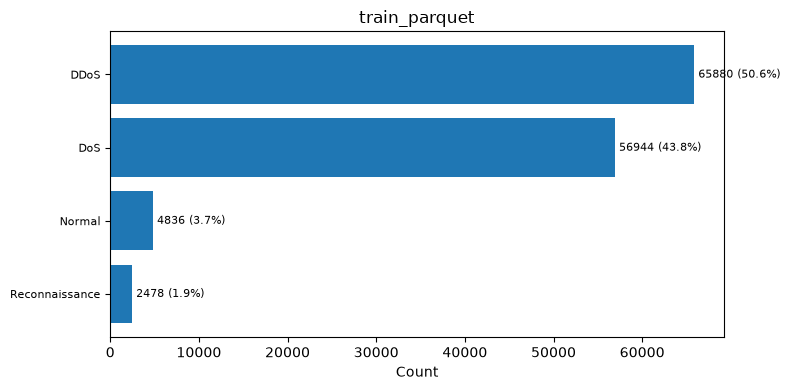

In [14]:
# class distribution with bar
plot_class_balance_bars(y_train_full, class_names, title="train_parquet")
plt.show()

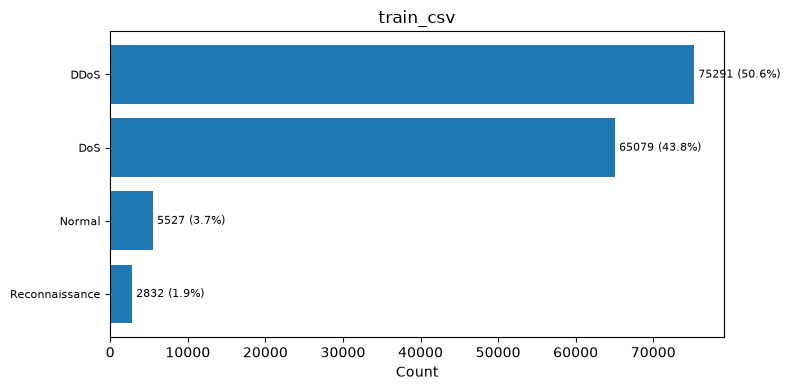

In [15]:
# class distribution with bar
plot_class_balance_bars(y_train_full_csv, class_names, title="train_csv")
plt.show()

In [16]:
if p_has_all_fros:
    print("Recommendation for MAQT train with FROZEN features: Parquet")
if c_has_all_fros:
    print("Recommendation for MAQT train with FROZEN features: CSV")

Recommendation for MAQT train with FROZEN features: CSV


## Dataset: CICIoT2023

In [17]:
dataset = "CICIoT2023"
dataset_alt = "CIC-IoT2023"

data_path = f"data/{dataset}/quantum"
data_path_alt = f"data/{dataset_alt}/quantum"

data_path_csv = f"data/FROZEN/{dataset}"
data_path_csv_alt = f"data/FROZEN/{dataset_alt}"

frozen_feat_path = "team-artifacts/teamC_week3_FROZEN_handoff.json"

target_col = "label_multiclass"
split_prefix = "q8"

In [18]:
df_p = pd.read_parquet(f"{data_path}/{split_prefix}_train.parquet")
df_p.head()

,n_pkts_total,duration,pkt_size_max,pkt_size_std,pkt_size_mean,n_bytes_total,pkt_size_min,protocol,label_multiclass,label_binary,label_family
0,0.032581,0.003637,0.125064,0.017957,1.419705e-01,1.057962,0.178744,3.141593,DDoS-RSTFINFlood,1,ddos
1,2.204835,0.378237,1.097552,1.699442,6.532626e-01,1.142228,0.322069,0.374114,BenignTraffic,0,benign
2,0.000000,0.000000,0.000000,0.000000,5.621659e-16,0.944141,0.000000,1.048536,DDoS-ICMP_Flood,1,ddos
3,0.000000,0.000071,0.298669,0.679082,1.579194e-01,1.075915,0.178744,3.141593,DDoS-TCP_Flood,1,ddos
4,0.009310,0.000000,0.122890,0.000000,1.419705e-01,1.057771,0.178744,3.141593,DDoS-RSTFINFlood,1,ddos


In [19]:
df_c = pd.read_csv(f"{data_path_csv}/train.csv")
df_c.head()

,duration,n_pkts_total,n_bytes_total,src_pkts,dst_pkts,src_bytes,dst_bytes,rate,rate_src,rate_dst,pkt_size_min,pkt_size_max,pkt_size_mean,pkt_size_std,iat,protocol,conn_state,label_multiclass,label_binary,label_family
0,0.114311,0.627152,0.005499,0.0,0.0,0.0,0.0,-0.306870,0.0,0.0,0.000000,0.050420,0.000000,0.166843,0.855064,0.000000,-1.368171,DDoS-RSTFINFlood,1,ddos
1,11.888079,59.170326,2.426720,0.0,0.0,0.0,0.0,0.744359,0.0,0.0,2.613771,22.605136,11.713125,15.789822,-314.863555,-1.322219,-1.217438,BenignTraffic,0,benign
2,0.000000,-0.250922,-3.264916,0.0,0.0,0.0,0.0,0.257804,0.0,0.0,-3.259715,-2.850162,-3.252384,0.000000,0.020018,-1.000000,0.000000,DDoS-ICMP_Flood,1,ddos
3,0.002218,-0.250922,0.521345,0.0,0.0,0.0,0.0,1.171933,0.0,0.0,0.000000,4.076821,0.365371,6.309469,-0.179558,0.000000,0.000000,DDoS-TCP_Flood,1,ddos
4,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,-0.079841,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.835176,0.000000,-1.368171,DDoS-RSTFINFlood,1,ddos


In [20]:
# check label columns
print("=" * 25, " Parquet labels ", "=" * 25)
print(df_p["label_multiclass"].unique())
print()
print(df_p["label_family"].unique())
print()
print("=" * 25, " CSV labels ", "=" * 25)
print(df_c["label_multiclass"].unique())
print()
print(df_c["label_family"].unique())

=========================  Parquet labels  =========================
<ArrowStringArray>
[       'DDoS-RSTFINFlood',           'BenignTraffic',
         'DDoS-ICMP_Flood',          'DDoS-TCP_Flood',
 'DDoS-SynonymousIP_Flood',          'DDoS-SlowLoris',
       'DDoS-PSHACK_Flood',           'DoS-TCP_Flood',
          'DDoS-UDP_Flood',           'DoS-UDP_Flood',
          'DoS-HTTP_Flood',          'DDoS-SYN_Flood',
           'DoS-SYN_Flood',        'MITM-ArpSpoofing',
    'DictionaryBruteForce',            'DNS_Spoofing',
  'DDoS-UDP_Fragmentation',          'Recon-PortScan',
       'VulnerabilityScan',                     'XSS',
         'DDoS-HTTP_Flood', 'DDoS-ICMP_Fragmentation',
  'DDoS-ACK_Fragmentation',     'Recon-HostDiscovery',
            'Recon-OSScan',        'BrowserHijacking',
         'Recon-PingSweep',            'SqlInjection',
        'Backdoor_Malware',        'CommandInjection',
        'Uploading_Attack']
Length: 31, dtype: str

<ArrowStringArray>
[               

In [21]:
# check NaNs
has_nan_p = df_p[target_col].isna().any()
has_nan_c = df_c[target_col].isna().any()
print(f"Parquet data has NaNs: {has_nan_p}")
print(f"CSV data has NaNs: {has_nan_c}")

Parquet data has NaNs: False
CSV data has NaNs: False


In [22]:
# get labels
class_names = sorted(df_p[target_col].dropna().unique())
class_names

['Backdoor_Malware',
 'BenignTraffic',
 'BrowserHijacking',
 'CommandInjection',
 'DDoS-ACK_Fragmentation',
 'DDoS-HTTP_Flood',
 'DDoS-ICMP_Flood',
 'DDoS-ICMP_Fragmentation',
 'DDoS-PSHACK_Flood',
 'DDoS-RSTFINFlood',
 'DDoS-SYN_Flood',
 'DDoS-SlowLoris',
 'DDoS-SynonymousIP_Flood',
 'DDoS-TCP_Flood',
 'DDoS-UDP_Flood',
 'DDoS-UDP_Fragmentation',
 'DNS_Spoofing',
 'DictionaryBruteForce',
 'DoS-HTTP_Flood',
 'DoS-SYN_Flood',
 'DoS-TCP_Flood',
 'DoS-UDP_Flood',
 'MITM-ArpSpoofing',
 'Recon-HostDiscovery',
 'Recon-OSScan',
 'Recon-PingSweep',
 'Recon-PortScan',
 'SqlInjection',
 'Uploading_Attack',
 'VulnerabilityScan',
 'XSS']

In [23]:
# load all data
try:
    X_train_full, y_train_full = load_split(
        data_path, f"{split_prefix}_train", target_col, class_names
    )
    X_val_full, y_val_full = load_split(
        data_path, f"{split_prefix}_val", target_col, class_names
    )
    X_cal_full, y_cal_full = load_split(
        data_path, f"{split_prefix}_calibration", target_col, class_names
    )
    X_test_full, y_test_full = load_split(
        data_path, f"{split_prefix}_test", target_col, class_names
    )
    X_zero_full, y_zero_full = load_split(
        data_path, f"{split_prefix}_zeroday", target_col, class_names
    )

    X_train_full_csv, y_train_full_csv = load_split(
        data_path_csv, "train", target_col, class_names, csv=True
    )
    X_cal_full_csv, y_cal_full_csv = load_split(
        data_path_csv, "calibration", target_col, class_names, csv=True
    )
    X_test_full_csv, y_test_full_csv = load_split(
        data_path_csv, "test", target_col, class_names, csv=True
    )
    X_zero_full_csv, y_zero_full_csv = load_split(
        data_path_csv, "zeroday", target_col, class_names, csv=True
    )
except:
    print("Fallback to another dataset location...")
    X_train_full, y_train_full = load_split(
        data_path_alt, f"{split_prefix}_train", target_col, class_names
    )
    X_val_full, y_val_full = load_split(
        data_path_alt, f"{split_prefix}_val", target_col, class_names
    )
    X_cal_full, y_cal_full = load_split(
        data_path_alt, f"{split_prefix}_calibration", target_col, class_names
    )
    X_test_full, y_test_full = load_split(
        data_path_alt, f"{split_prefix}_test", target_col, class_names
    )
    X_zero_full, y_zero_full = load_split(
        data_path_alt, f"{split_prefix}_zeroday", target_col, class_names
    )

    X_train_full_csv, y_train_full_csv = load_split(
        data_path_csv_alt, "train", target_col, class_names, csv=True
    )
    X_cal_full_csv, y_cal_full_csv = load_split(
        data_path_csv_alt, "calibration", target_col, class_names, csv=True
    )
    X_test_full_csv, y_test_full_csv = load_split(
        data_path_csv_alt, "test", target_col, class_names, csv=True
    )
    X_zero_full_csv, y_zero_full_csv = load_split(
        data_path_csv_alt, "zeroday", target_col, class_names, csv=True
    )

# check shape
print(
    f"train_parquet : {X_train_full.shape, y_train_full.shape}\n\
val_parquet   : {X_val_full.shape, y_val_full.shape}\n\
cal_parquet   : {X_cal_full.shape, y_cal_full.shape}\n\
test_parquet  : {X_test_full.shape, y_test_full.shape}\n\
zero_parquet  : {X_zero_full.shape, y_zero_full.shape}\n\
train_csv     : {X_train_full_csv.shape, y_train_full_csv.shape}\n\
cal_csv       : {X_cal_full_csv.shape, y_cal_full_csv.shape}\n\
test_csv      : {X_test_full_csv.shape, y_test_full_csv.shape}\n\
zero_csv      : {X_zero_full_csv.shape, y_zero_full_csv.shape}\n"
)

train_parquet : ((132166, 8), (132166,))
val_parquet   : ((18883, 8), (18883,))
cal_parquet   : ((18883, 8), (18883,))
test_parquet  : ((18883, 8), (18883,))
zero_parquet  : ((10984, 8), (10984,))
train_csv     : ((151049, 17), (151049,))
cal_csv       : ((18883, 17), (18883,))
test_csv      : ((18883, 17), (18883,))
zero_csv      : ((10984, 17), (10984,))



In [24]:
# load FROZEN features
handoff = json.loads(Path(frozen_feat_path).read_text())

try:
    FEATURE_COLS = list(handoff["frozen_subsets"][dataset]["features"])
    print(f"Team C selector: {handoff['frozen_subsets'][dataset]['selector']}")
except:
    print("Fallback to another dataset location...")
    FEATURE_COLS = list(handoff["frozen_subsets"][dataset_alt]["features"])
    print(f"Team C selector: {handoff['frozen_subsets'][dataset_alt]['selector']}")
print(f"k={len(FEATURE_COLS)} features: {FEATURE_COLS}")

Team C selector: MI
k=10 features: ['duration', 'n_pkts_total', 'n_bytes_total', 'rate', 'pkt_size_min', 'pkt_size_max', 'pkt_size_mean', 'iat', 'protocol', 'conn_state']


In [25]:
# check CSV train is a combination
data_combined = X_train_full.shape[0] + X_val_full.shape[0] == X_train_full_csv.shape[0]
data_combined_col = X_train_full.shape[1] < X_train_full_csv.shape[1]
print(f"Row-wise: Parquet train + Parquet val = CSV train?: {data_combined}")
print(f"Col-wise: Parquet train < CSV train (more feature)?: {data_combined_col}")
print("=" * 100)

# check if other sets are same: Parquet vs CSV
same_size_cal = X_cal_full.shape[0] == X_cal_full_csv.shape[0]
same_size_test = X_test_full.shape[0] == X_test_full_csv.shape[0]
same_size_zero = X_zero_full.shape[0] == X_zero_full_csv.shape[0]
print(f"Row-wise: Parquet cal = CSV cal? : {same_size_cal}")
print(f"Row-wise: Parquet test = CSV test? : {same_size_cal}")
print(f"Row-wise: Parquet zero = CSV zero? : {same_size_cal}")
print("=" * 100)

# check columns
p_cols, c_cols, fro_cols = set(df_p.columns), set(df_c.columns), set(FEATURE_COLS)
print(f"Parquet has these cols: {p_cols}")
print()
print(f"CSV has these cols: {c_cols}")
print()
print(f"We want these cols: {fro_cols}")
print("=" * 100)

# FROZEN features: Parquet or CSV
p_has_all_fros = len(fro_cols - p_cols) == 0
c_has_all_fros = len(fro_cols - c_cols) == 0
print(f"Does Parquet train have required FROZEN features?: {p_has_all_fros}")
print(f"Does CSV train have required FROZEN features?: {c_has_all_fros}")

Row-wise: Parquet train + Parquet val = CSV train?: True
Col-wise: Parquet train < CSV train (more feature)?: True
Row-wise: Parquet cal = CSV cal? : True
Row-wise: Parquet test = CSV test? : True
Row-wise: Parquet zero = CSV zero? : True
Parquet has these cols: {'n_pkts_total', 'duration', 'pkt_size_mean', 'label_family', 'pkt_size_min', 'label_multiclass', 'n_bytes_total', 'pkt_size_std', 'protocol', 'label_binary', 'pkt_size_max'}

CSV has these cols: {'duration', 'label_multiclass', 'rate_dst', 'dst_bytes', 'pkt_size_max', 'src_pkts', 'src_bytes', 'pkt_size_std', 'iat', 'label_binary', 'rate', 'n_pkts_total', 'pkt_size_mean', 'label_family', 'pkt_size_min', 'n_bytes_total', 'conn_state', 'rate_src', 'dst_pkts', 'protocol'}

We want these cols: {'n_pkts_total', 'duration', 'pkt_size_mean', 'pkt_size_min', 'n_bytes_total', 'conn_state', 'iat', 'protocol', 'pkt_size_max', 'rate'}
Does Parquet train have required FROZEN features?: False
Does CSV train have required FROZEN features?: Tr

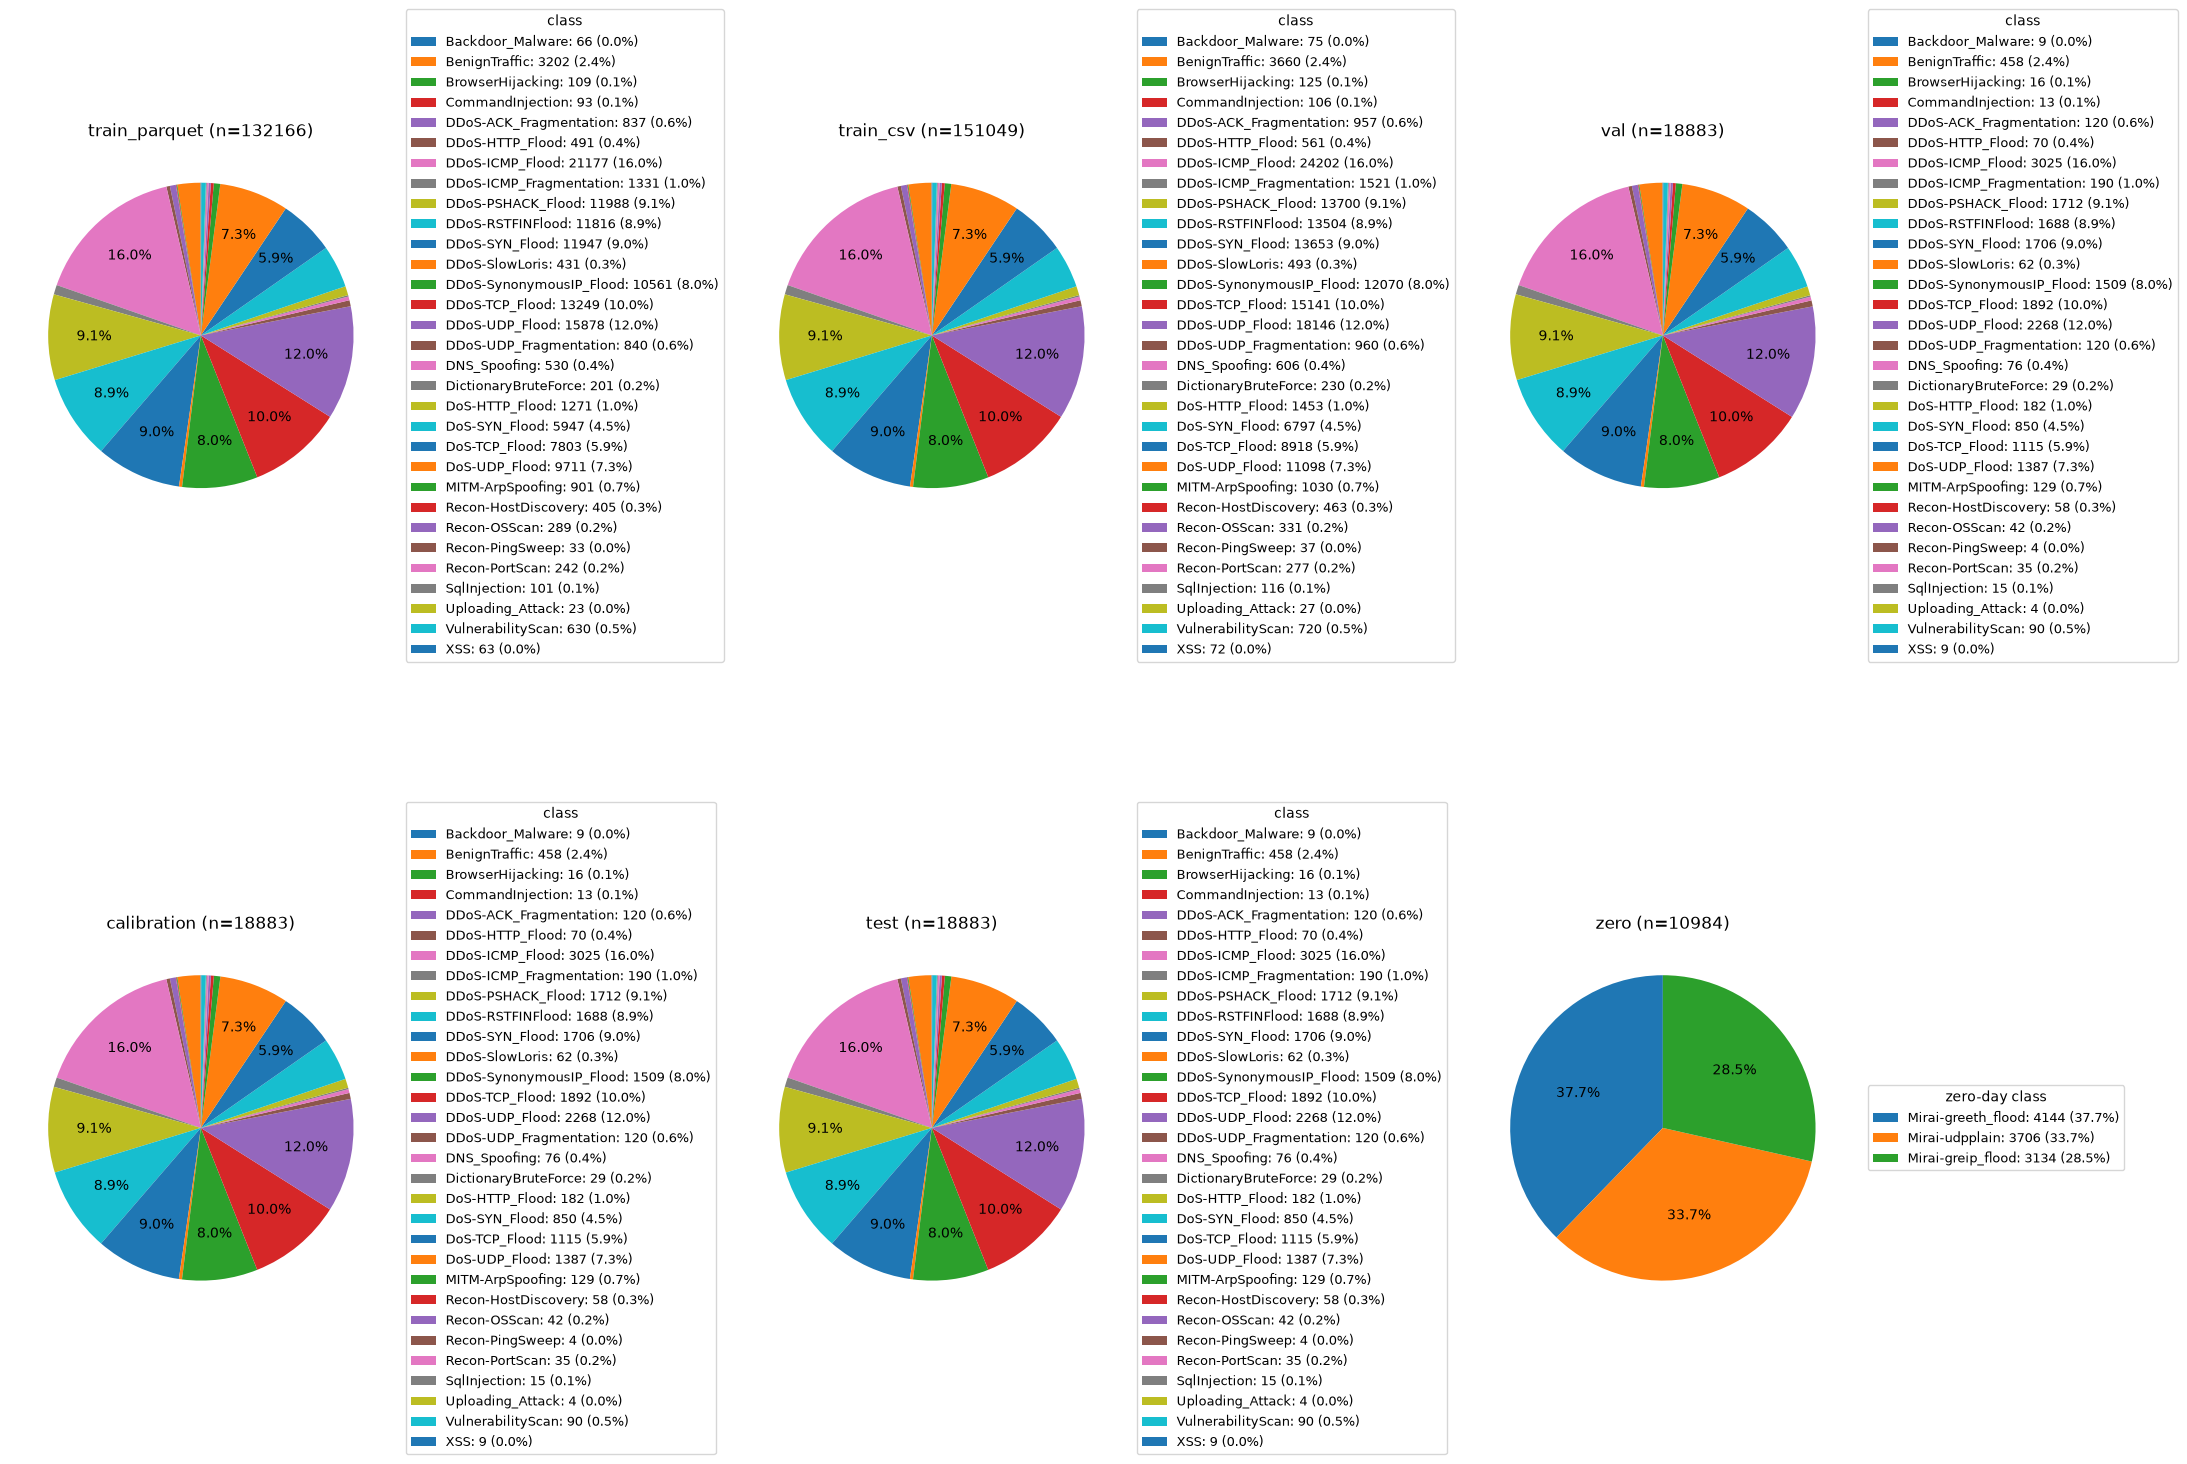

In [26]:
# class distribution with pie chart
splits = {
    "train_parquet": y_train_full,
    "train_csv": y_train_full_csv,
    "val": y_val_full,
    "calibration": y_cal_full,
    "test": y_test_full,
    # skip cal, test, zero sets from CSV <- same with those from Parquet
}

fig, axes = plt.subplots(2, 3, figsize=(22, 16))
axes = axes.ravel()

# train_parquet, train_csv, val, cal, test
for ax, (name, y) in zip(axes, splits.items()):
    plot_class_balance_pie(y, class_names, title=f"{name} (n={len(to_np_y(y))})", ax=ax)

# zero-day
## show its own labels (not known class_names)
ax = axes[len(splits)]
y0 = to_np_y(y_zero_full)

## reload just for EDA
df_zero = pd.read_parquet(f"{data_path}/{split_prefix}_zeroday.parquet")
df_zero = df_zero[df_zero[target_col].notna()].reset_index(drop=True)

vc = df_zero[target_col].value_counts()
ax.pie(
    vc.values,
    labels=None,
    autopct=lambda p: f"{p:.1f}%" if p >= 1 else "",
    startangle=90,
)
ax.legend(
    [f"{lab}: {n} ({100 * n / vc.sum():.1f}%)" for lab, n in vc.items()],
    title="zero-day class",
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    fontsize=9,
)
ax.set_title(f"zero (n={len(df_zero)})")

plt.tight_layout()
plt.show()

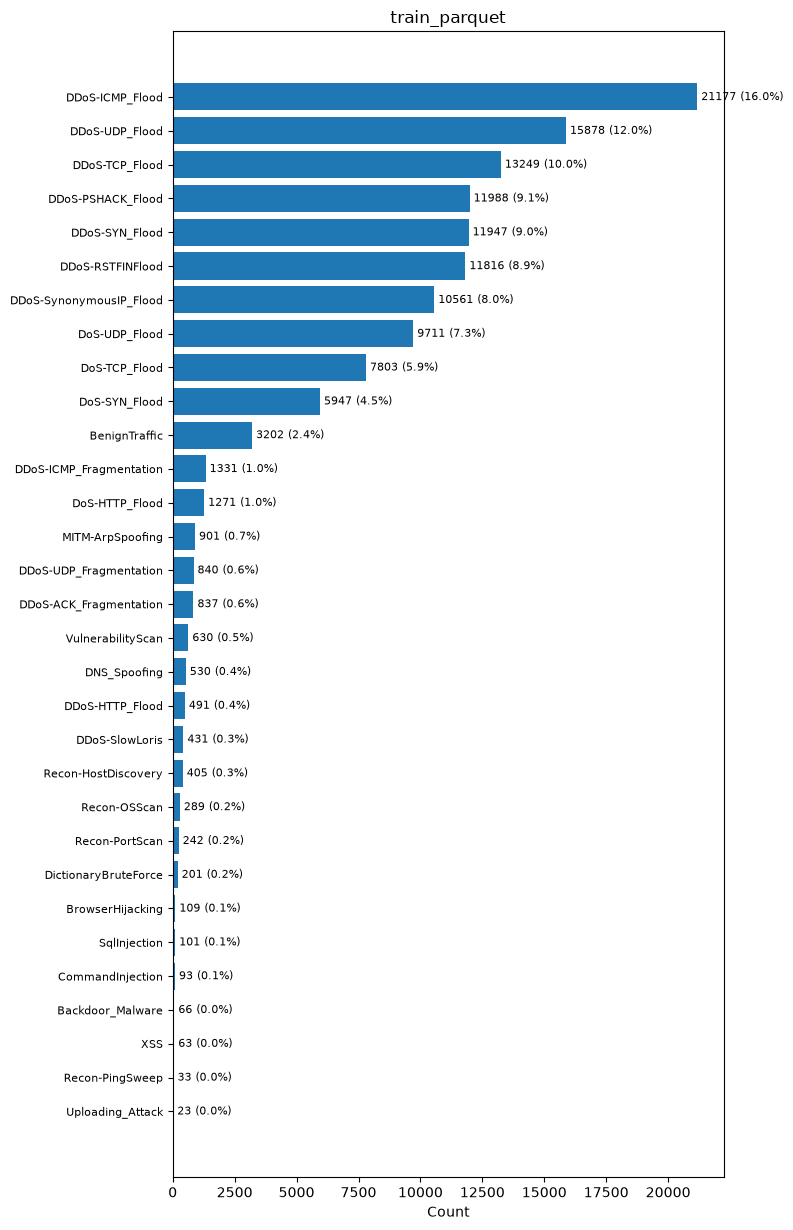

In [27]:
# class distribution with bar
plot_class_balance_bars(y_train_full, class_names, title="train_parquet")
plt.show()

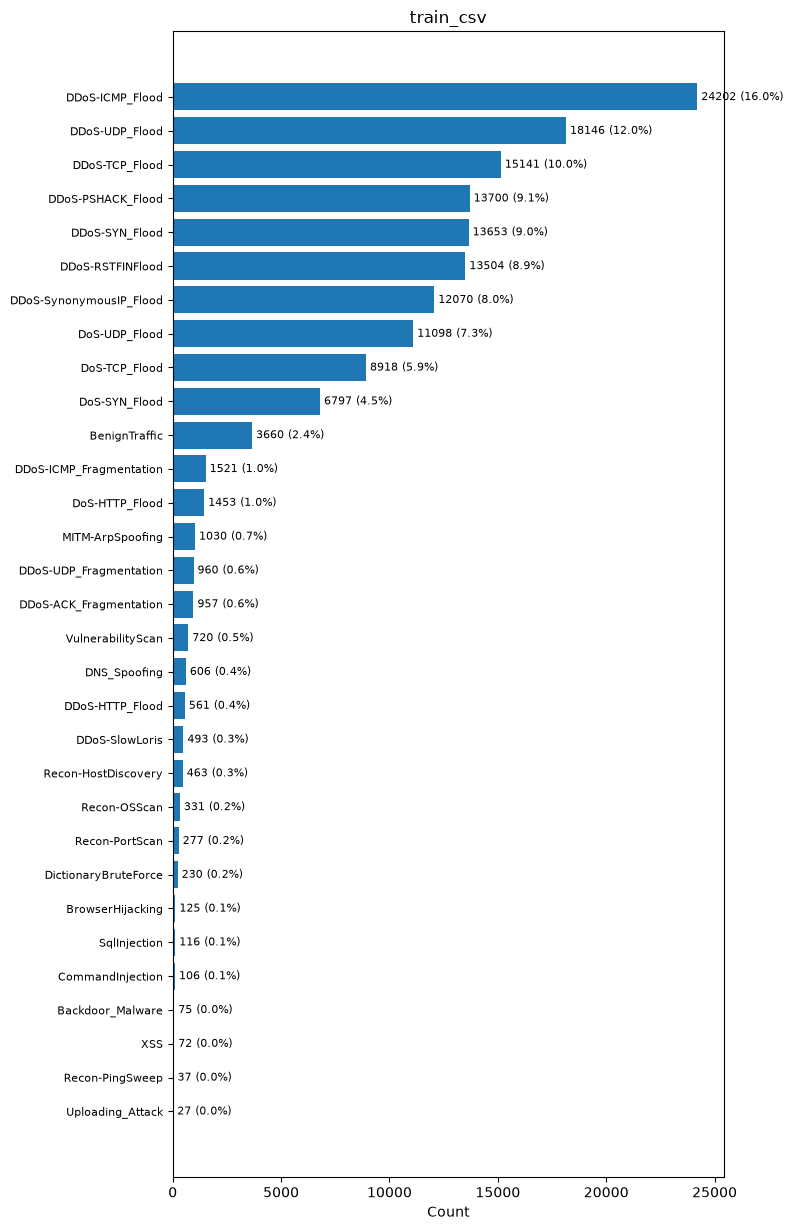

In [28]:
# class distribution with bar
plot_class_balance_bars(y_train_full_csv, class_names, title="train_csv")
plt.show()

In [29]:
if p_has_all_fros:
    print("Recommendation for MAQT train with FROZEN features: Parquet")
if c_has_all_fros:
    print("Recommendation for MAQT train with FROZEN features: CSV")

Recommendation for MAQT train with FROZEN features: CSV


## Dataset: UNSW-NB15

In [30]:
dataset = "UNSW-NB15"
dataset_alt = "UNSW_NB15"

data_path = f"data/{dataset}/quantum"
data_path_alt = f"data/{dataset_alt}/quantum"

data_path_csv = f"data/FROZEN/{dataset}"
data_path_csv_alt = f"data/FROZEN/{dataset_alt}"

frozen_feat_path = "team-artifacts/teamC_week3_FROZEN_handoff.json"

target_col = "label_multiclass"
split_prefix = "q8"

In [31]:
df_p = pd.read_parquet(f"{data_path}/{split_prefix}_train.parquet")
df_p.head()

,rate_dst,iat,rate,rate_src,duration,dst_bytes,conn_state,dst_pkts,label_multiclass,label_binary,label_family
0,2.660748,1.000199,1.193106,1.289150,1.240526,2.600926,3.141593,2.190781,Exploits,1,exploits
1,1.300715,1.148865,0.717575,1.401026,0.207269,0.850290,0.374600,0.370983,Normal,0,benign
2,0.000000,0.002482,2.641954,2.489562,0.000007,0.000000,0.168227,0.000000,Generic,1,generic
3,1.547429,1.337109,0.657683,1.161471,0.572600,1.232307,3.141593,0.809729,Normal,0,benign
4,2.342302,0.643438,1.282489,1.506876,0.034630,1.447465,3.141593,0.741966,Normal,0,benign


In [32]:
df_c = pd.read_csv(f"{data_path_csv}/train.csv")
df_c.head()

,duration,n_pkts_total,n_bytes_total,src_pkts,dst_pkts,src_bytes,dst_bytes,rate,rate_src,rate_dst,pkt_size_min,pkt_size_max,pkt_size_mean,pkt_size_std,iat,protocol,conn_state,label_multiclass,label_binary,label_family
0,1.731948,2.945547,1.419156,2.427756,3.437999,0.964095,2.766445,0.342217,-0.201876,0.996449,0.0,0.0,-0.396060,0.0,-0.031287,0.0,0.000000,Exploits,1,exploits
1,-0.257683,-0.791538,-0.362735,-0.689398,-1.092216,-0.072596,-0.896015,-0.164247,-0.013491,-0.447216,0.0,0.0,0.719197,0.0,0.116867,0.0,-0.745321,Normal,0,benign
2,-0.656785,-1.723042,-1.741032,-1.632998,-2.015743,-1.483457,-2.674885,1.885314,1.819467,-1.827915,0.0,0.0,-1.168109,0.0,-1.025566,0.0,-0.800910,Generic,1,generic
3,0.445796,-0.027190,-0.288256,-0.186041,0.000000,-0.402562,-0.096807,-0.228035,-0.416871,-0.185331,0.0,0.0,-0.454305,0.0,0.304462,0.0,0.000000,Normal,0,benign
4,-0.590115,-0.379589,-0.375972,-0.689398,-0.168690,-0.817816,0.353319,0.437415,0.164747,0.658421,0.0,0.0,-0.421855,0.0,-0.386818,0.0,0.000000,Normal,0,benign


In [33]:
# check label columns
print("=" * 25, " Parquet labels ", "=" * 25)
print(df_p["label_multiclass"].unique())
print()
print(df_p["label_family"].unique())
print()
print("=" * 25, " CSV labels ", "=" * 25)
print(df_c["label_multiclass"].unique())
print()
print(df_c["label_family"].unique())

=========================  Parquet labels  =========================
<ArrowStringArray>
[      'Exploits',         'Normal',        'Generic',       'Analysis',
 'Reconnaissance',            'DoS',        'Fuzzers',       'Backdoor']
Length: 8, dtype: str

<ArrowStringArray>
[                   'exploits',                      'benign',
                     'generic',                    'analysis',
                       'recon',                         'dos',
                     'fuzzers', 'backdoor_malware_ransomware']
Length: 8, dtype: str

=========================  CSV labels  =========================
<ArrowStringArray>
[      'Exploits',         'Normal',        'Generic',       'Analysis',
 'Reconnaissance',            'DoS',        'Fuzzers',       'Backdoor']
Length: 8, dtype: str

<ArrowStringArray>
[                   'exploits',                      'benign',
                     'generic',                    'analysis',
                       'recon',                    

In [34]:
# check NaNs
has_nan_p = df_p[target_col].isna().any()
has_nan_c = df_c[target_col].isna().any()
print(f"Parquet data has NaNs: {has_nan_p}")
print(f"CSV data has NaNs: {has_nan_c}")

Parquet data has NaNs: False
CSV data has NaNs: False


In [35]:
# get labels
class_names = sorted(df_p[target_col].dropna().unique())
class_names

['Analysis',
 'Backdoor',
 'DoS',
 'Exploits',
 'Fuzzers',
 'Generic',
 'Normal',
 'Reconnaissance']

In [36]:
# load all data
try:
    X_train_full, y_train_full = load_split(
        data_path, f"{split_prefix}_train", target_col, class_names
    )
    X_val_full, y_val_full = load_split(
        data_path, f"{split_prefix}_val", target_col, class_names
    )
    X_cal_full, y_cal_full = load_split(
        data_path, f"{split_prefix}_calibration", target_col, class_names
    )
    X_test_full, y_test_full = load_split(
        data_path, f"{split_prefix}_test", target_col, class_names
    )
    X_zero_full, y_zero_full = load_split(
        data_path, f"{split_prefix}_zeroday", target_col, class_names
    )

    X_train_full_csv, y_train_full_csv = load_split(
        data_path_csv, "train", target_col, class_names, csv=True
    )
    X_cal_full_csv, y_cal_full_csv = load_split(
        data_path_csv, "calibration", target_col, class_names, csv=True
    )
    X_test_full_csv, y_test_full_csv = load_split(
        data_path_csv, "test", target_col, class_names, csv=True
    )
    X_zero_full_csv, y_zero_full_csv = load_split(
        data_path_csv, "zeroday", target_col, class_names, csv=True
    )
except:
    print("Fallback to another dataset location...")
    X_train_full, y_train_full = load_split(
        data_path_alt, f"{split_prefix}_train", target_col, class_names
    )
    X_val_full, y_val_full = load_split(
        data_path_alt, f"{split_prefix}_val", target_col, class_names
    )
    X_cal_full, y_cal_full = load_split(
        data_path_alt, f"{split_prefix}_calibration", target_col, class_names
    )
    X_test_full, y_test_full = load_split(
        data_path_alt, f"{split_prefix}_test", target_col, class_names
    )
    X_zero_full, y_zero_full = load_split(
        data_path_alt, f"{split_prefix}_zeroday", target_col, class_names
    )

    X_train_full_csv, y_train_full_csv = load_split(
        data_path_csv_alt, "train", target_col, class_names, csv=True
    )
    X_cal_full_csv, y_cal_full_csv = load_split(
        data_path_csv_alt, "calibration", target_col, class_names, csv=True
    )
    X_test_full_csv, y_test_full_csv = load_split(
        data_path_csv_alt, "test", target_col, class_names, csv=True
    )
    X_zero_full_csv, y_zero_full_csv = load_split(
        data_path_csv_alt, "zeroday", target_col, class_names, csv=True
    )

# check shape
print(
    f"train_parquet : {X_train_full.shape, y_train_full.shape}\n\
val_parquet   : {X_val_full.shape, y_val_full.shape}\n\
cal_parquet   : {X_cal_full.shape, y_cal_full.shape}\n\
test_parquet  : {X_test_full.shape, y_test_full.shape}\n\
zero_parquet  : {X_zero_full.shape, y_zero_full.shape}\n\
train_csv     : {X_train_full_csv.shape, y_train_full_csv.shape}\n\
cal_csv       : {X_cal_full_csv.shape, y_cal_full_csv.shape}\n\
test_csv      : {X_test_full_csv.shape, y_test_full_csv.shape}\n\
zero_csv      : {X_zero_full_csv.shape, y_zero_full_csv.shape}\n"
)

train_parquet : ((71094, 8), (71094,))
val_parquet   : ((10121, 8), (10121,))
cal_parquet   : ((10112, 8), (10112,))
test_parquet  : ((10086, 8), (10086,))
zero_parquet  : ((1216, 8), (1216,))
train_csv     : ((81215, 17), (81215,))
cal_csv       : ((10112, 17), (10112,))
test_csv      : ((10086, 17), (10086,))
zero_csv      : ((1216, 17), (1216,))



In [37]:
# load FROZEN features
handoff = json.loads(Path(frozen_feat_path).read_text())

try:
    FEATURE_COLS = list(handoff["frozen_subsets"][dataset]["features"])
    print(f"Team C selector: {handoff['frozen_subsets'][dataset]['selector']}")
except:
    print("Fallback to another dataset location...")
    FEATURE_COLS = list(handoff["frozen_subsets"][dataset_alt]["features"])
    print(f"Team C selector: {handoff['frozen_subsets'][dataset_alt]['selector']}")
print(f"k={len(FEATURE_COLS)} features: {FEATURE_COLS}")

Team C selector: RF
k=10 features: ['duration', 'n_pkts_total', 'n_bytes_total', 'src_bytes', 'dst_bytes', 'rate', 'rate_src', 'rate_dst', 'pkt_size_mean', 'iat']


In [38]:
# check CSV train is a combination
data_combined = X_train_full.shape[0] + X_val_full.shape[0] == X_train_full_csv.shape[0]
data_combined_col = X_train_full.shape[1] < X_train_full_csv.shape[1]
print(f"Row-wise: Parquet train + Parquet val = CSV train?: {data_combined}")
print(f"Col-wise: Parquet train < CSV train (more feature)?: {data_combined_col}")
print("=" * 100)

# check if other sets are same: Parquet vs CSV
same_size_cal = X_cal_full.shape[0] == X_cal_full_csv.shape[0]
same_size_test = X_test_full.shape[0] == X_test_full_csv.shape[0]
same_size_zero = X_zero_full.shape[0] == X_zero_full_csv.shape[0]
print(f"Row-wise: Parquet cal = CSV cal? : {same_size_cal}")
print(f"Row-wise: Parquet test = CSV test? : {same_size_cal}")
print(f"Row-wise: Parquet zero = CSV zero? : {same_size_cal}")
print("=" * 100)

# check columns
p_cols, c_cols, fro_cols = set(df_p.columns), set(df_c.columns), set(FEATURE_COLS)
print(f"Parquet has these cols: {p_cols}")
print()
print(f"CSV has these cols: {c_cols}")
print()
print(f"We want these cols: {fro_cols}")
print("=" * 100)

# FROZEN features: Parquet or CSV
p_has_all_fros = len(fro_cols - p_cols) == 0
c_has_all_fros = len(fro_cols - c_cols) == 0
print(f"Does Parquet train have required FROZEN features?: {p_has_all_fros}")
print(f"Does CSV train have required FROZEN features?: {c_has_all_fros}")

Row-wise: Parquet train + Parquet val = CSV train?: True
Col-wise: Parquet train < CSV train (more feature)?: True
Row-wise: Parquet cal = CSV cal? : True
Row-wise: Parquet test = CSV test? : True
Row-wise: Parquet zero = CSV zero? : True
Parquet has these cols: {'duration', 'label_family', 'dst_pkts', 'label_multiclass', 'conn_state', 'iat', 'rate_dst', 'dst_bytes', 'label_binary', 'rate', 'rate_src'}

CSV has these cols: {'duration', 'label_multiclass', 'rate_dst', 'dst_bytes', 'pkt_size_max', 'src_pkts', 'src_bytes', 'pkt_size_std', 'iat', 'label_binary', 'rate', 'n_pkts_total', 'pkt_size_mean', 'label_family', 'pkt_size_min', 'n_bytes_total', 'conn_state', 'rate_src', 'dst_pkts', 'protocol'}

We want these cols: {'n_pkts_total', 'duration', 'pkt_size_mean', 'n_bytes_total', 'src_bytes', 'iat', 'rate_dst', 'dst_bytes', 'rate', 'rate_src'}
Does Parquet train have required FROZEN features?: False
Does CSV train have required FROZEN features?: True


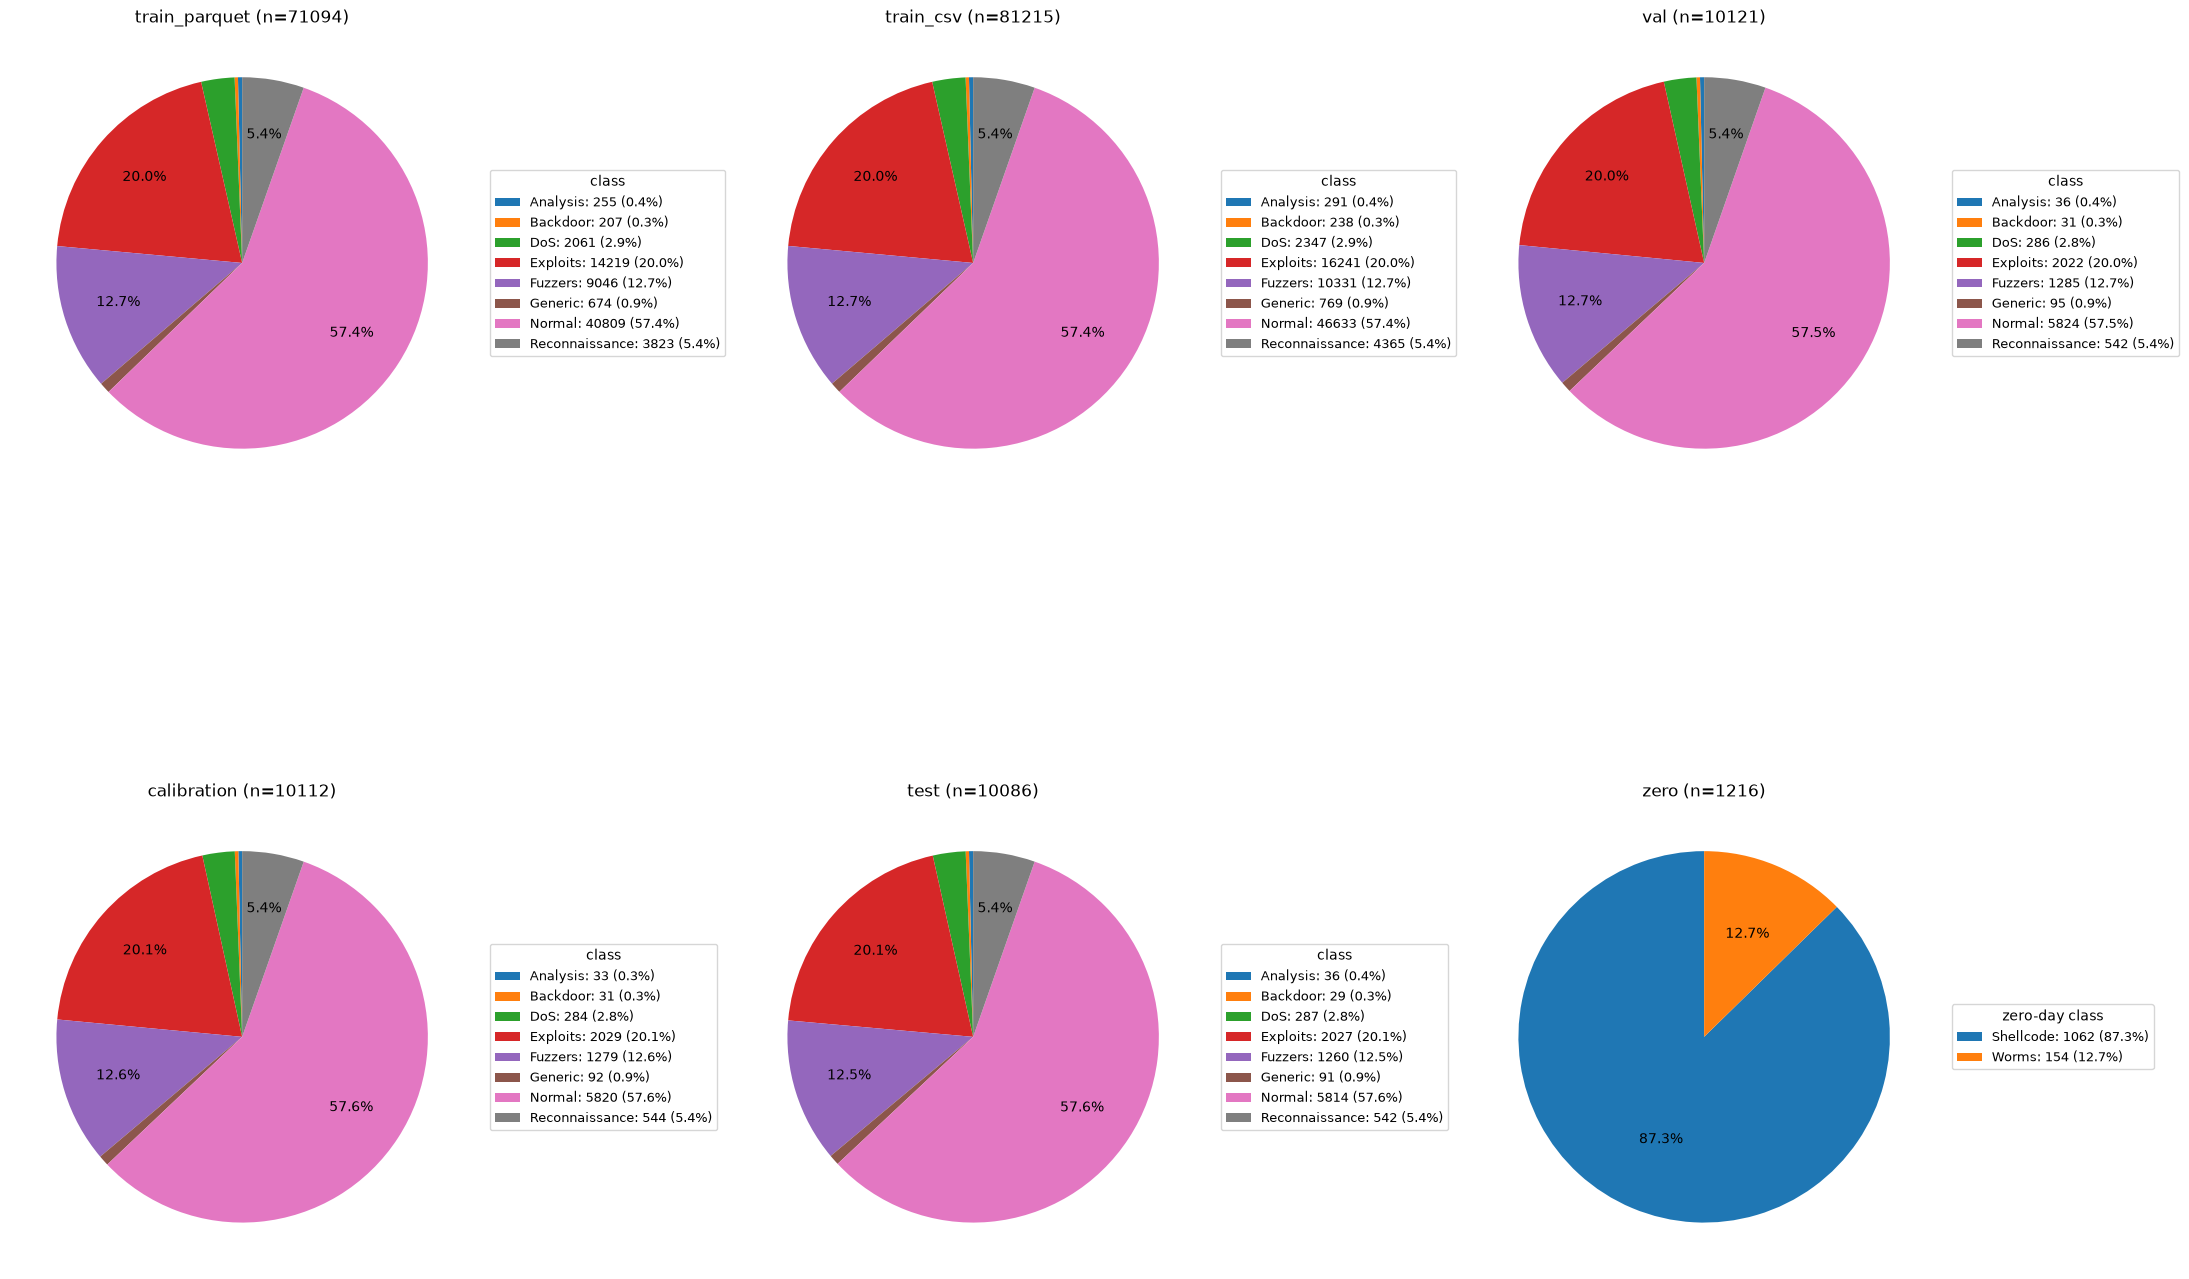

In [39]:
# class distribution with pie chart
splits = {
    "train_parquet": y_train_full,
    "train_csv": y_train_full_csv,
    "val": y_val_full,
    "calibration": y_cal_full,
    "test": y_test_full,
    # skip cal, test, zero sets from CSV <- same with those from Parquet
}

fig, axes = plt.subplots(2, 3, figsize=(22, 16))
axes = axes.ravel()

# train_parquet, train_csv, val, cal, test
for ax, (name, y) in zip(axes, splits.items()):
    plot_class_balance_pie(y, class_names, title=f"{name} (n={len(to_np_y(y))})", ax=ax)

# zero-day
## show its own labels (not known class_names)
ax = axes[len(splits)]
y0 = to_np_y(y_zero_full)

## reload just for EDA
df_zero = pd.read_parquet(f"{data_path}/{split_prefix}_zeroday.parquet")
df_zero = df_zero[df_zero[target_col].notna()].reset_index(drop=True)

vc = df_zero[target_col].value_counts()
ax.pie(
    vc.values,
    labels=None,
    autopct=lambda p: f"{p:.1f}%" if p >= 1 else "",
    startangle=90,
)
ax.legend(
    [f"{lab}: {n} ({100 * n / vc.sum():.1f}%)" for lab, n in vc.items()],
    title="zero-day class",
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    fontsize=9,
)
ax.set_title(f"zero (n={len(df_zero)})")

plt.tight_layout()
plt.show()

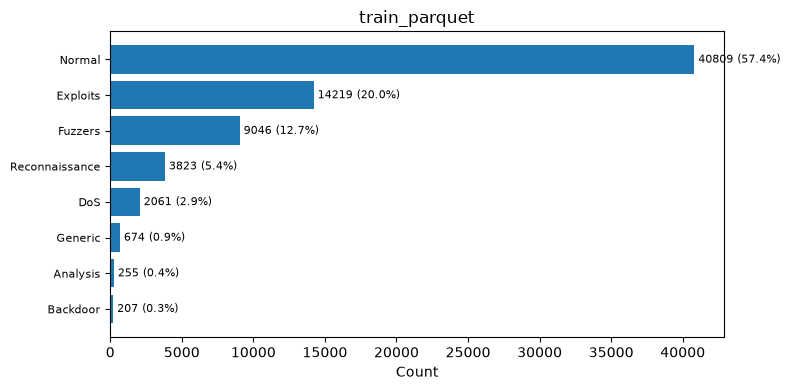

In [40]:
# class distribution with bar
plot_class_balance_bars(y_train_full, class_names, title="train_parquet")
plt.show()

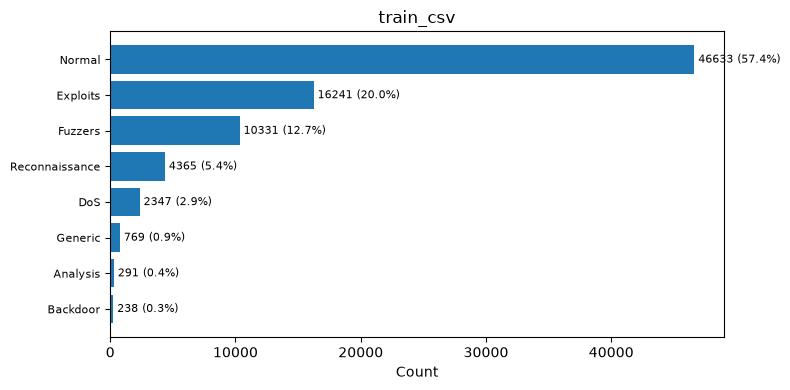

In [41]:
# class distribution with bar
plot_class_balance_bars(y_train_full_csv, class_names, title="train_csv")
plt.show()

In [42]:
if p_has_all_fros:
    print("Recommendation for MAQT train with FROZEN features: Parquet")
if c_has_all_fros:
    print("Recommendation for MAQT train with FROZEN features: CSV")

Recommendation for MAQT train with FROZEN features: CSV
